In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error

In [2]:
path_test = "C:/Users/Ihab/Desktop/Preprocessing/test_v2.csv"
path_train = "C:/Users/Ihab/Desktop/Preprocessing/train_v2.csv"
train = pd.read_csv(path_train)
test = pd.read_csv(path_test)

In [3]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
(train['Alley'].isnull().sum()/len(train))*100

93.76712328767123

In [7]:
(train['PoolQC'].isnull().sum()/len(train))*100

99.52054794520548

In [8]:
(train['Fence'].isnull().sum()/len(train))*100

80.75342465753424

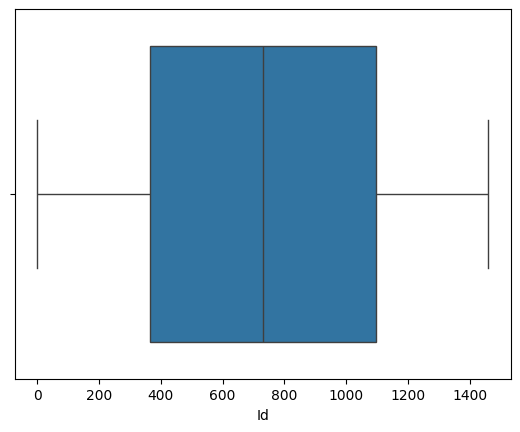

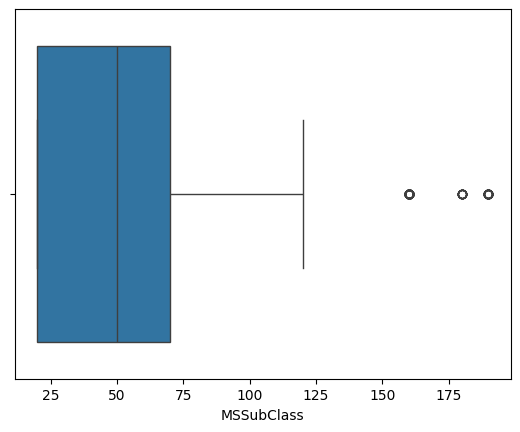

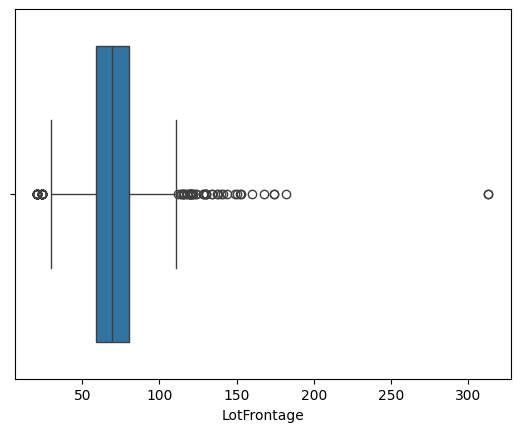

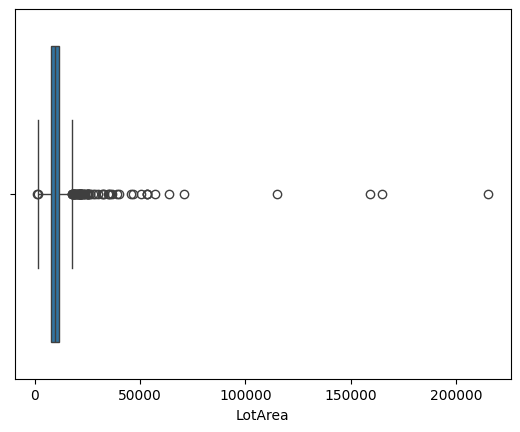

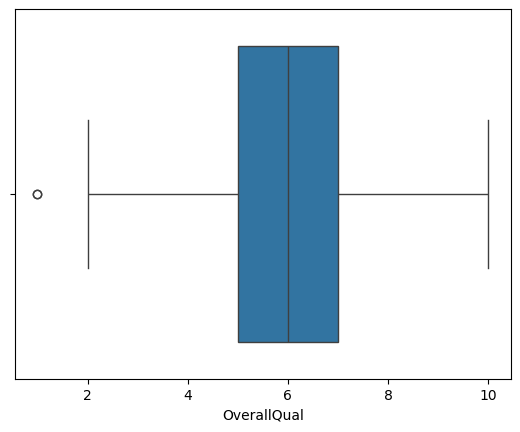

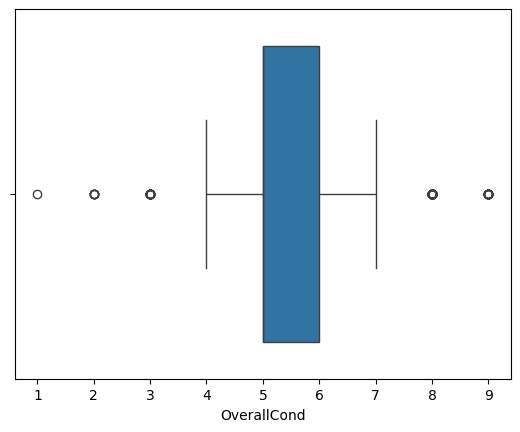

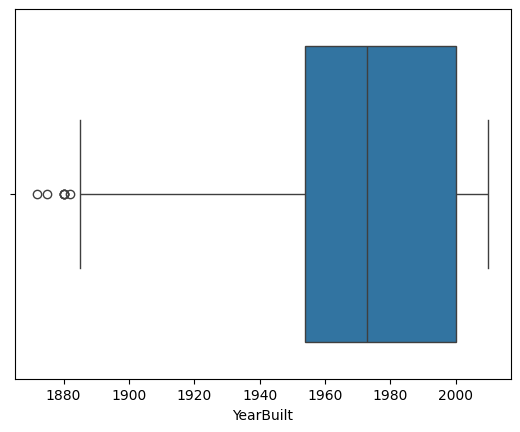

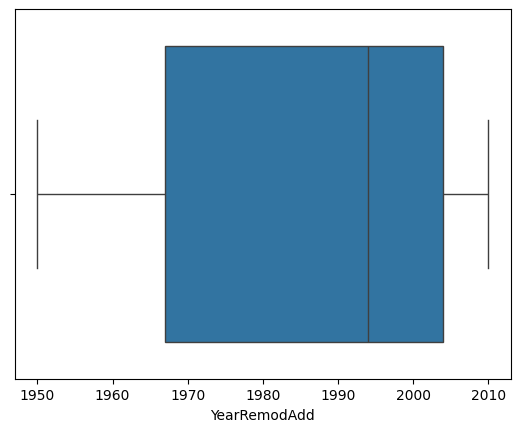

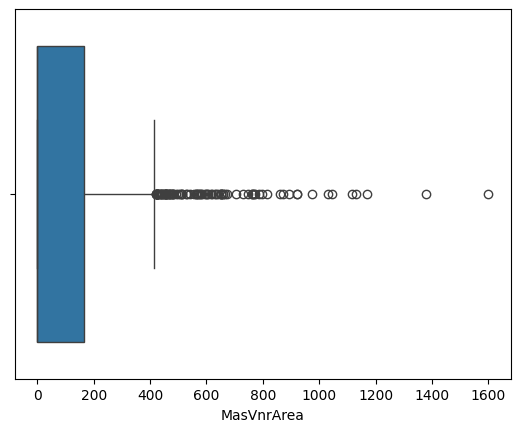

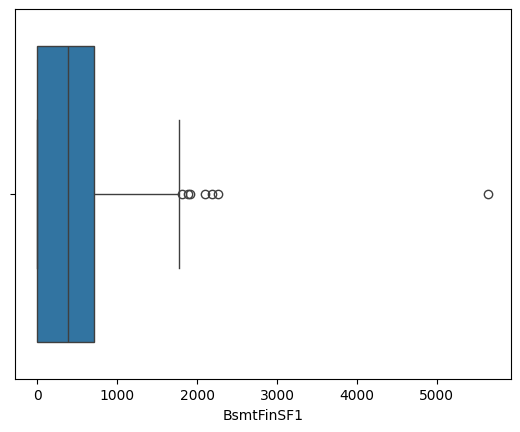

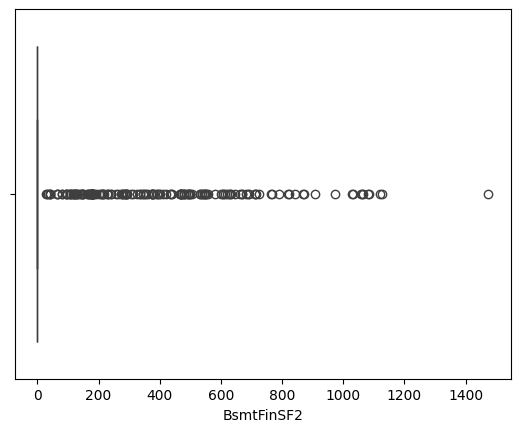

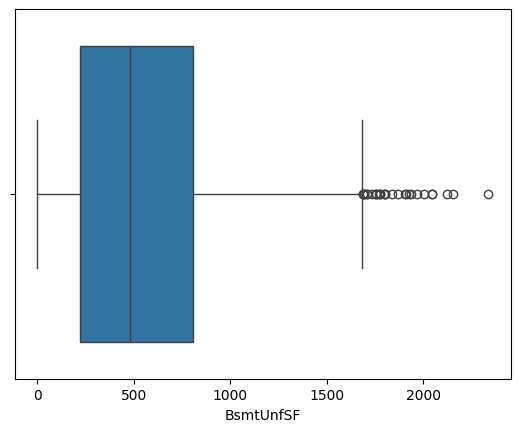

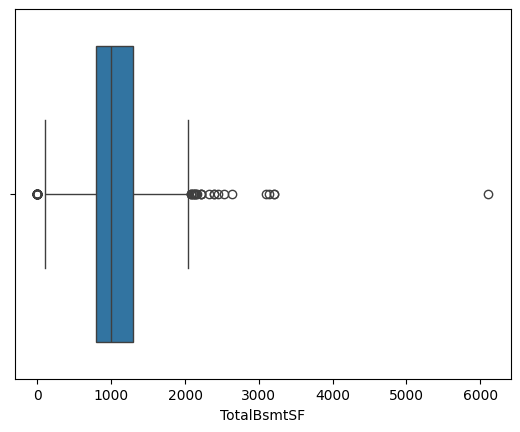

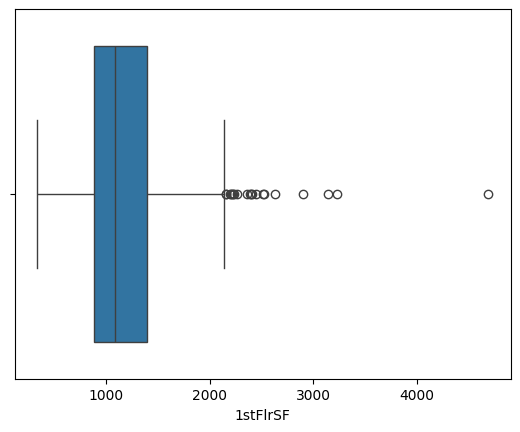

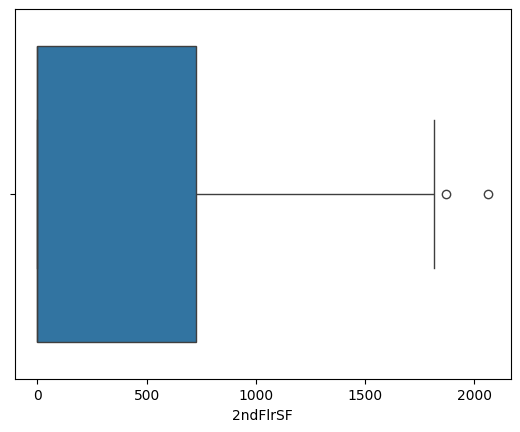

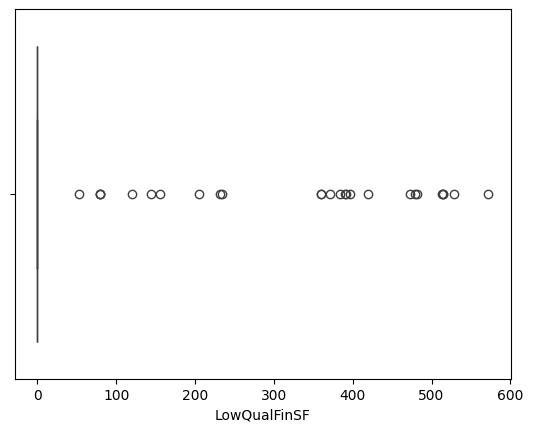

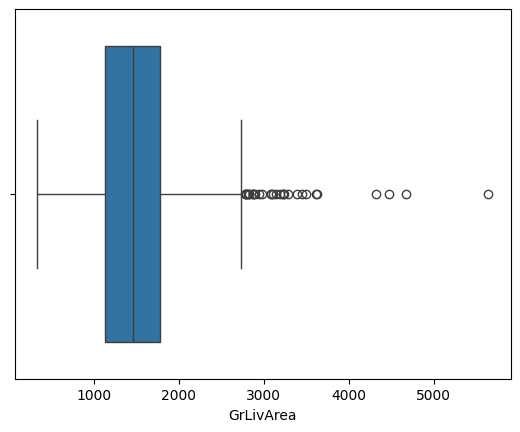

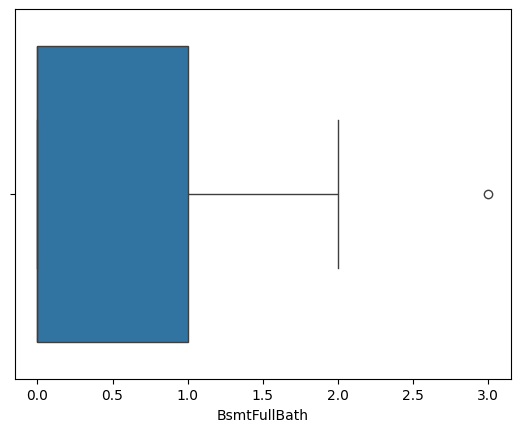

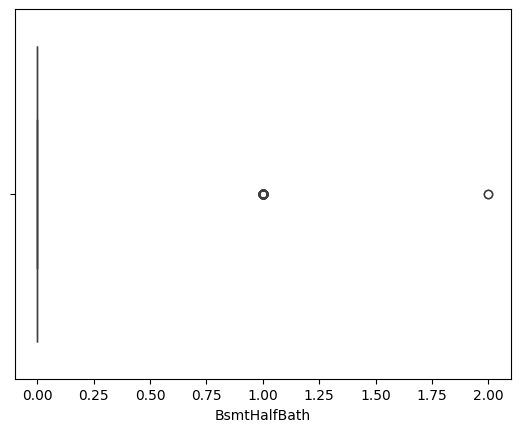

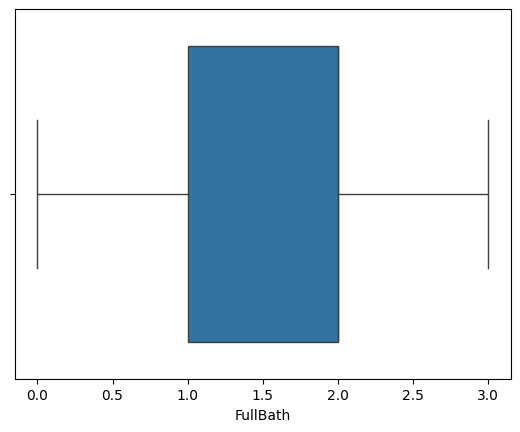

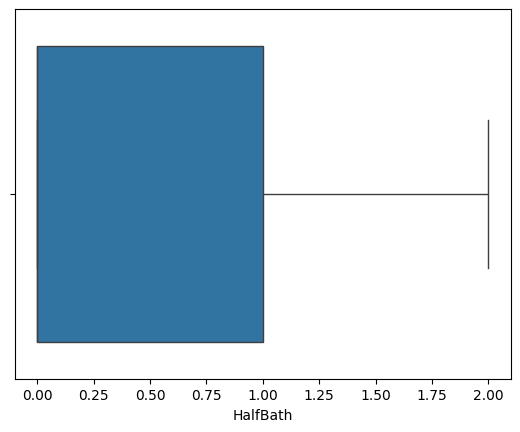

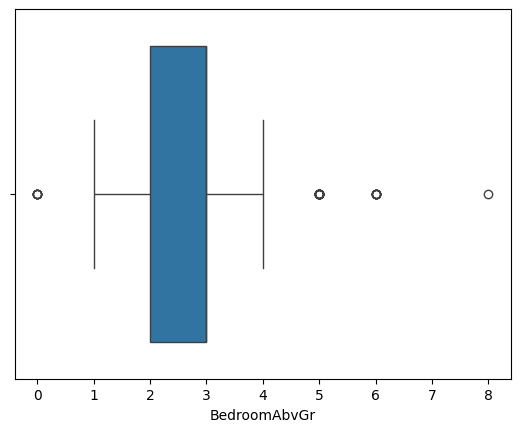

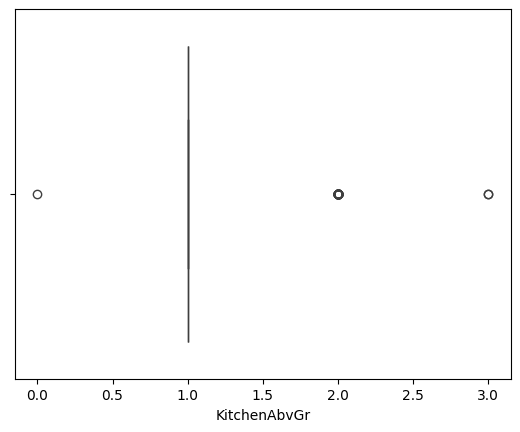

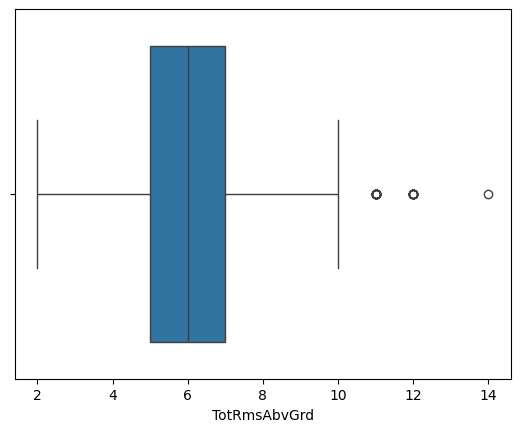

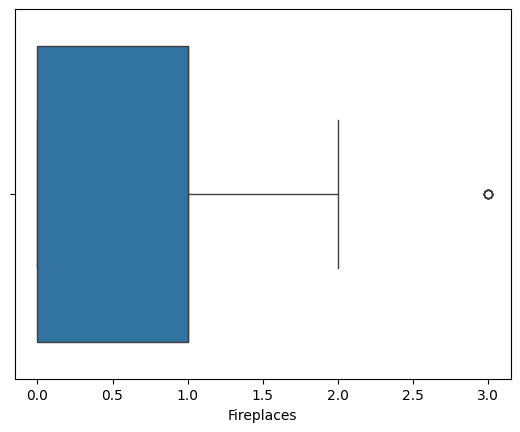

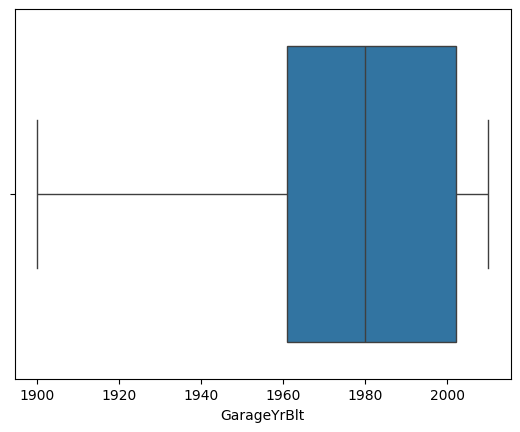

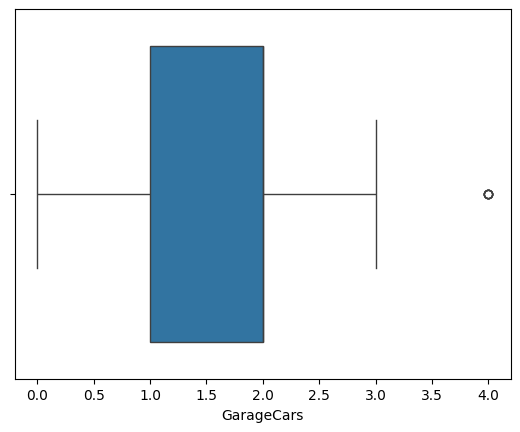

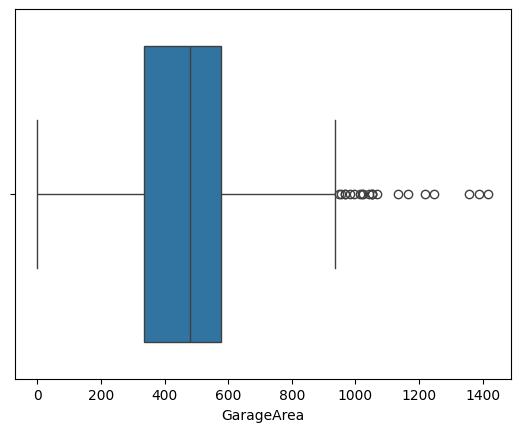

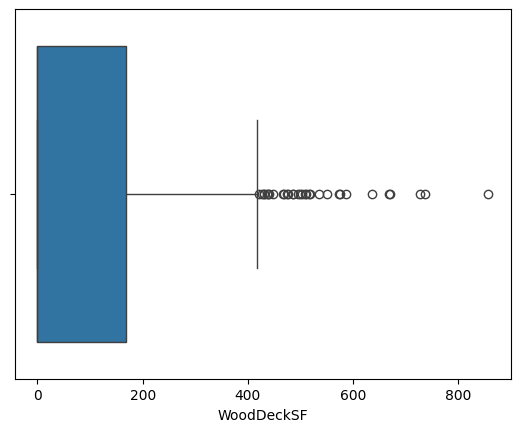

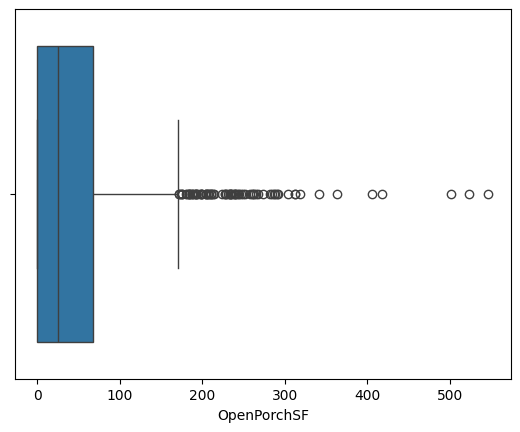

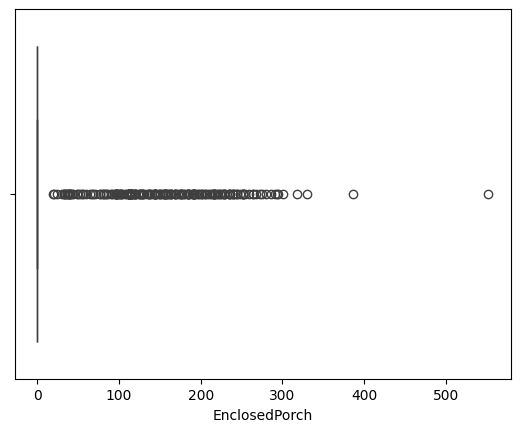

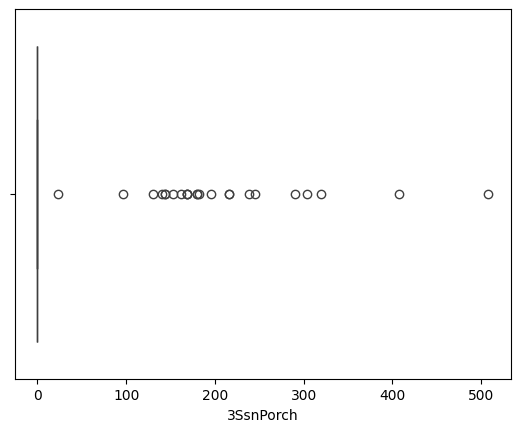

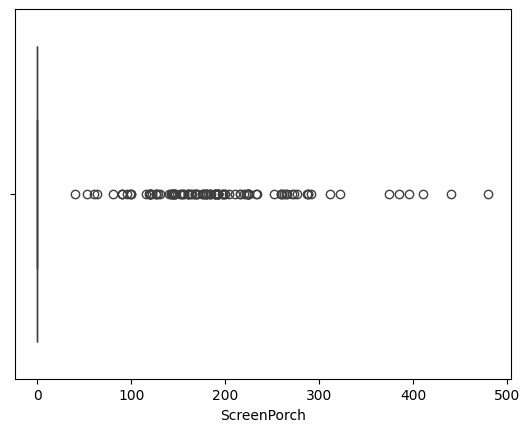

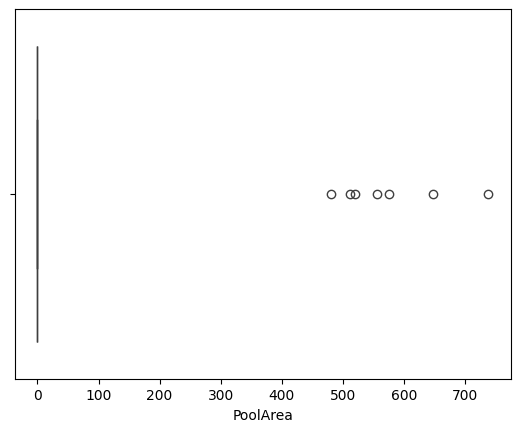

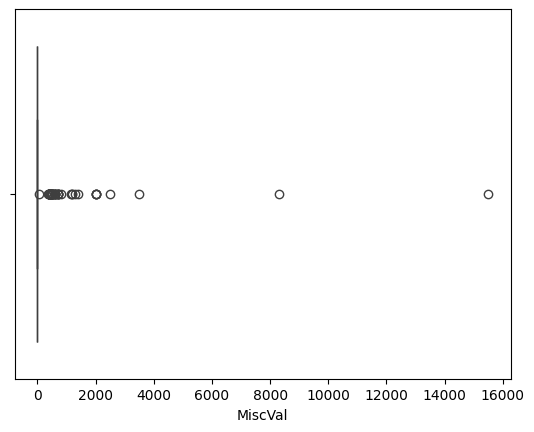

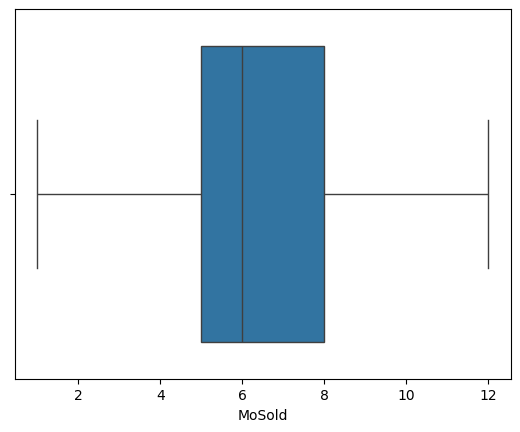

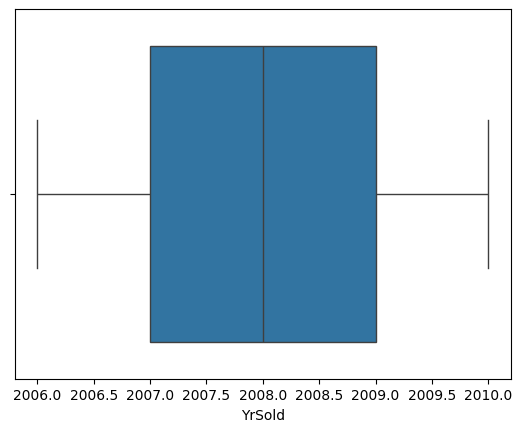

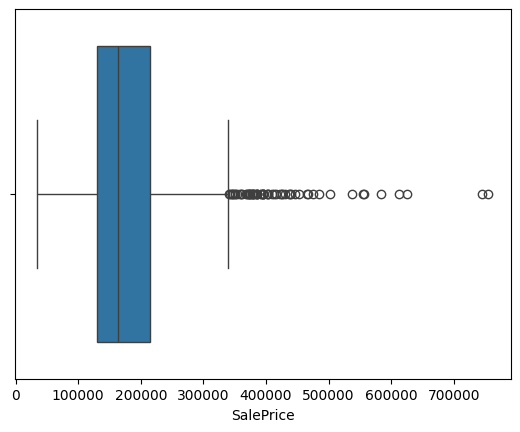

In [9]:
for i in train.select_dtypes(include='number').columns:
    sns.boxplot(data=train,x=i)
    plt.show()

In [10]:
def clean(df):
    x = ['OverallQual','GrLivArea','TotalBsmtSF','GarageCars','GarageArea','1stFlrSF','2ndFlrSF','YearBuilt','YearRemodAdd','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath','TotRmsAbvGrd','BedroomAbvGr','KitchenQual','Fireplaces','Foundation','ExterQual','Neighborhood','GarageFinish','CentralAir','MoSold','YrSold','MasVnrArea','BsmtFinSF1','BsmtUnfSF','WoodDeckSF','OpenPorchSF','HouseStyle','SalePrice']
    df_new = df[x].copy()
    return df_new

In [11]:
train = clean(train)

In [12]:
def clean_2(df):
    x = ['OverallQual','GrLivArea','TotalBsmtSF','GarageCars','GarageArea','1stFlrSF','2ndFlrSF','YearBuilt','YearRemodAdd','FullBath','HalfBath','BsmtFullBath','BsmtHalfBath','TotRmsAbvGrd','BedroomAbvGr','KitchenQual','Fireplaces','Foundation','ExterQual','Neighborhood','GarageFinish','CentralAir','MoSold','YrSold','MasVnrArea','BsmtFinSF1','BsmtUnfSF','WoodDeckSF','OpenPorchSF','HouseStyle']
    df_new = df[x].copy()
    return df_new

In [13]:
test = clean_2(test)

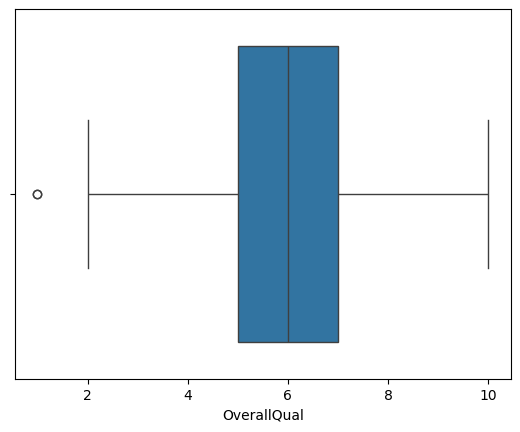

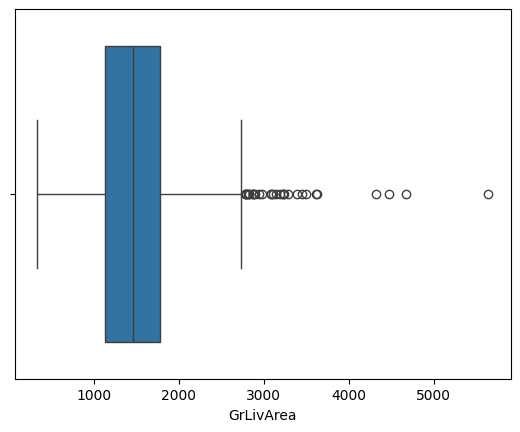

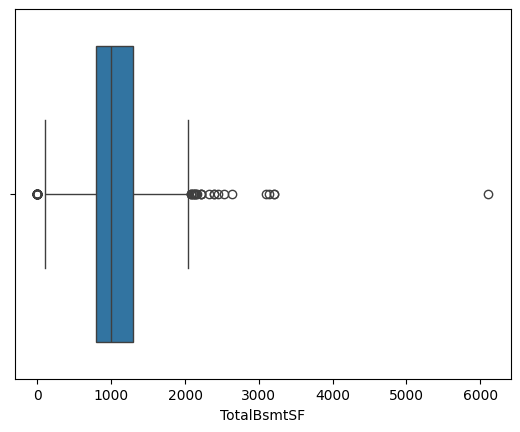

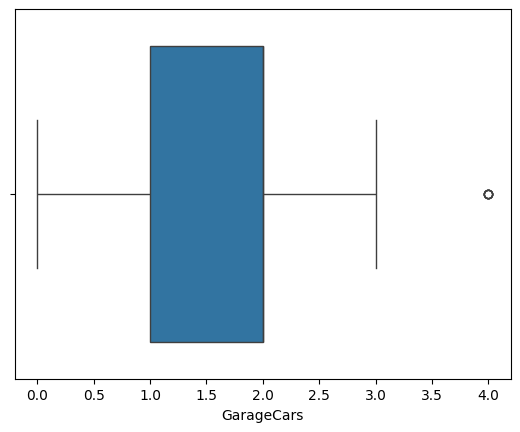

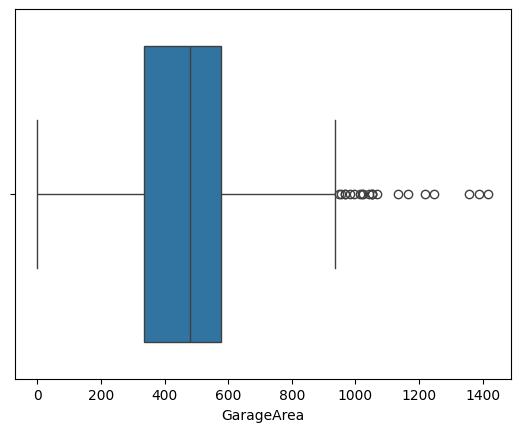

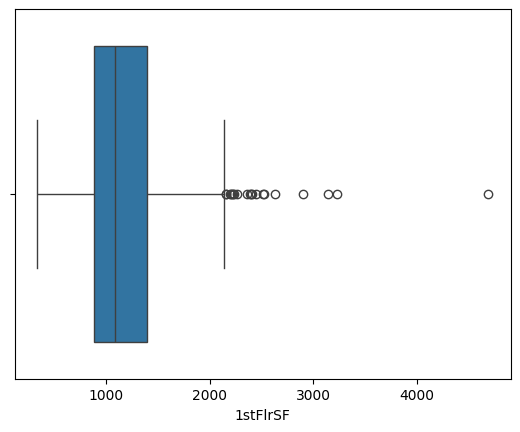

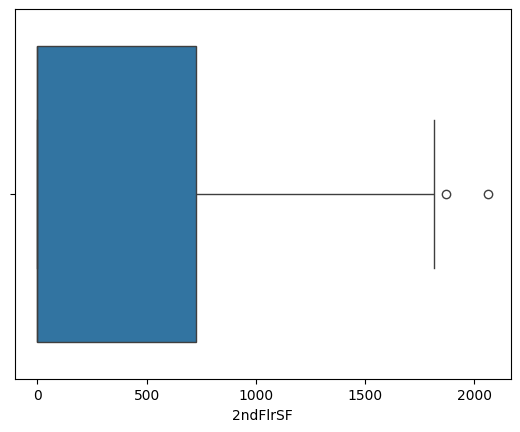

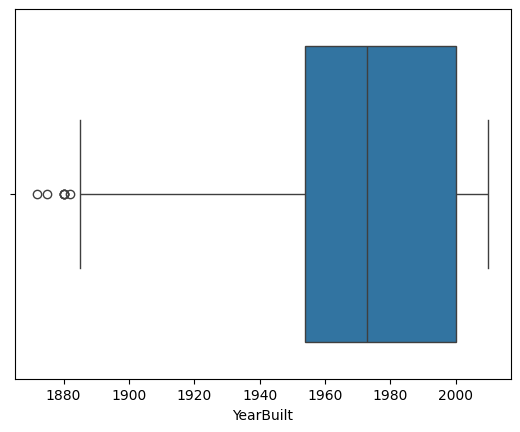

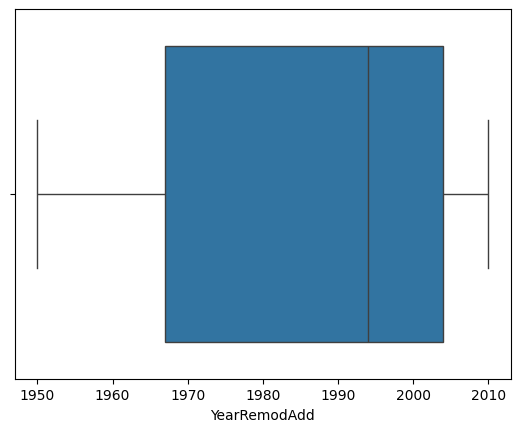

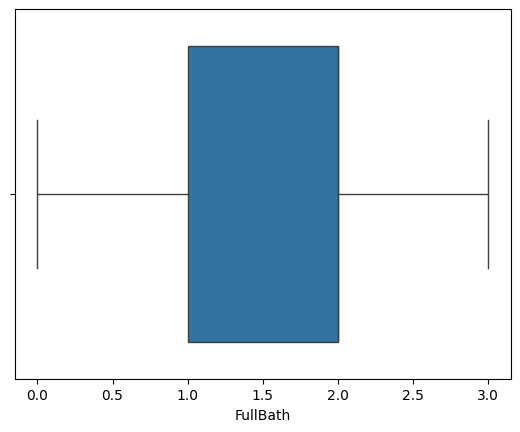

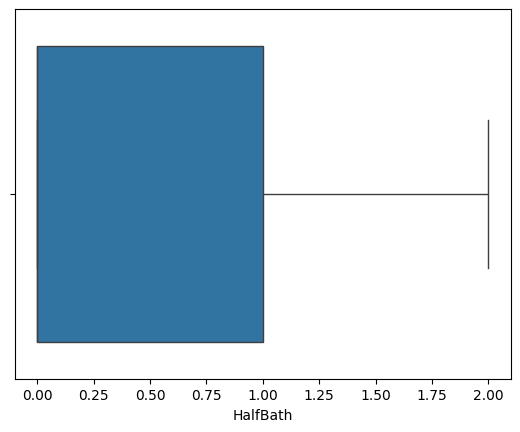

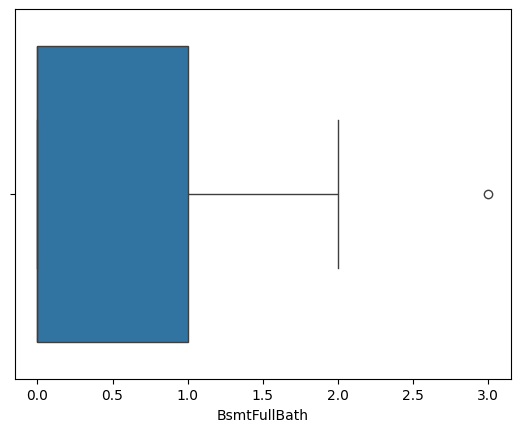

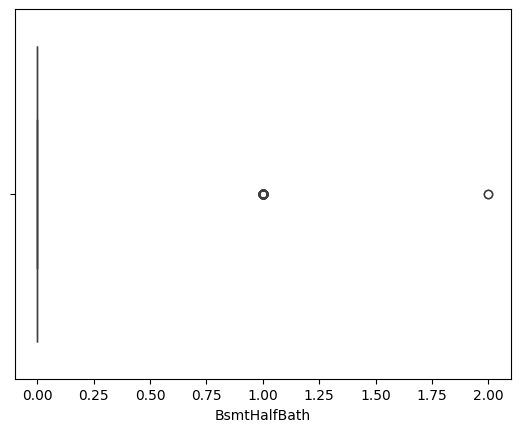

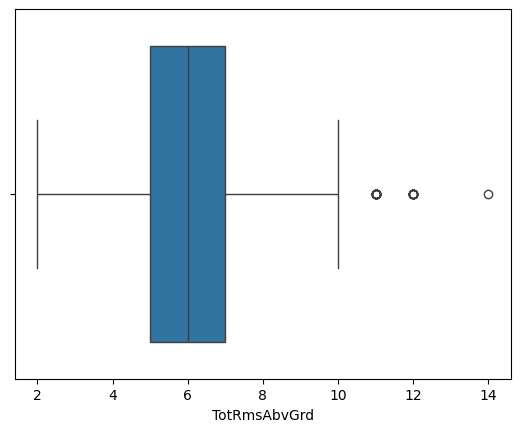

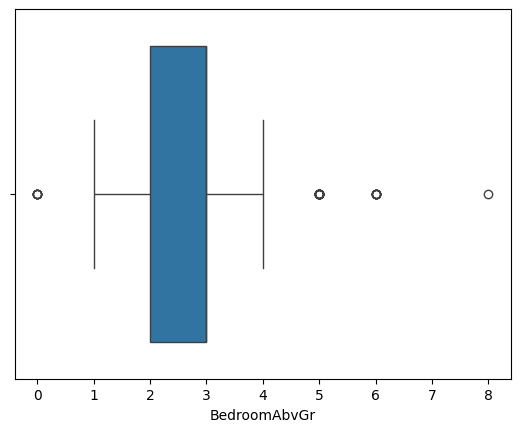

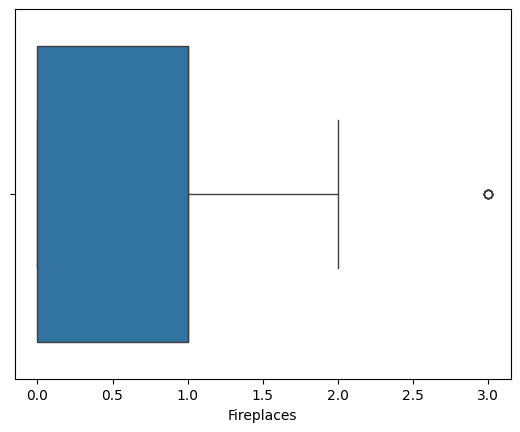

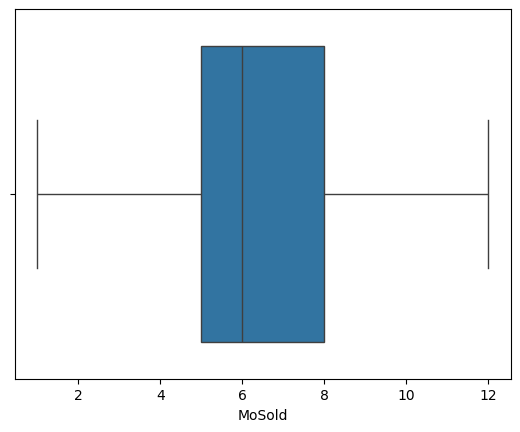

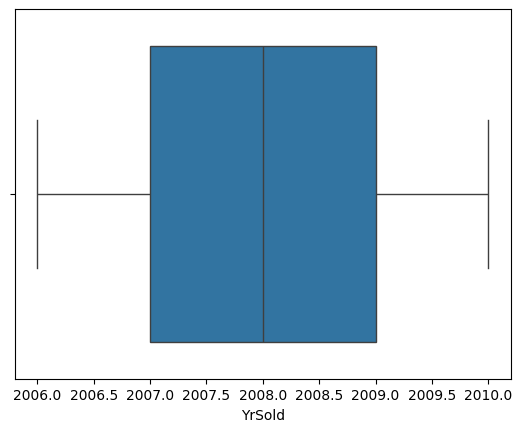

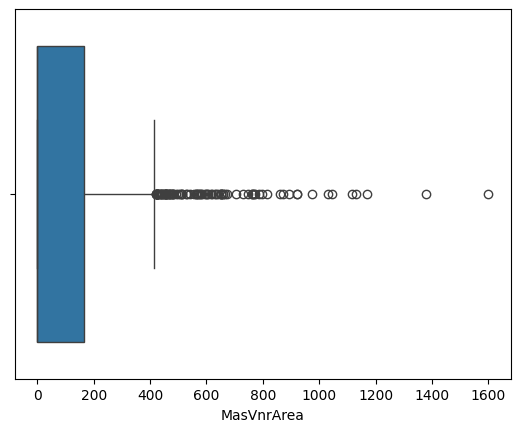

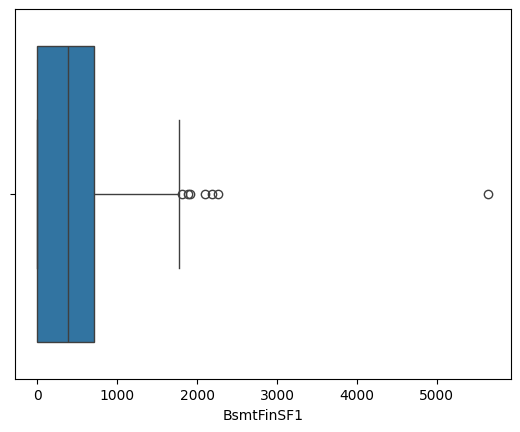

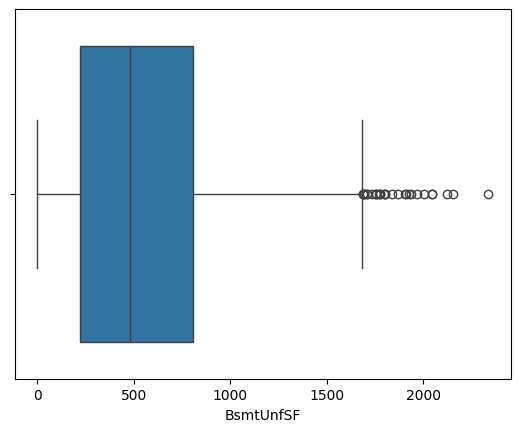

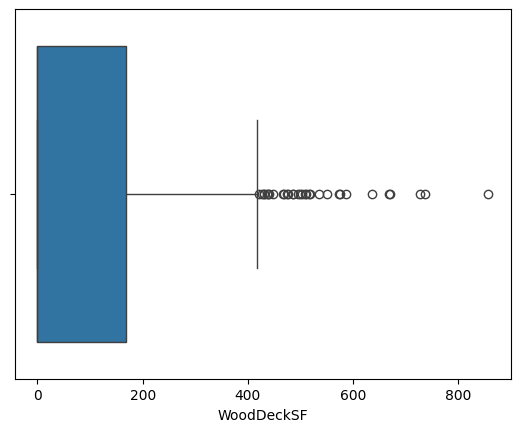

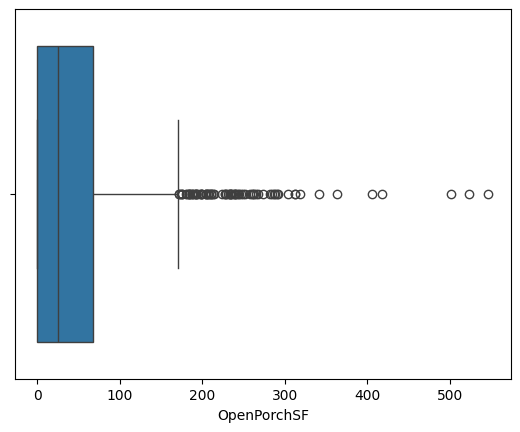

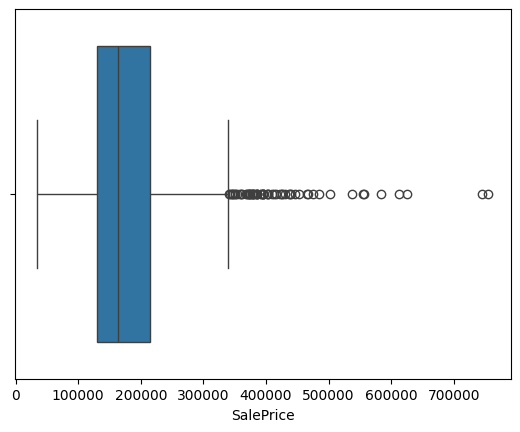

In [14]:
for i in train.select_dtypes(include='number').columns:
    sns.boxplot(data=train,x=i)
    plt.show()

In [15]:
train.isnull().sum()

OverallQual      0
GrLivArea        0
TotalBsmtSF      0
GarageCars       0
GarageArea       0
1stFlrSF         0
2ndFlrSF         0
YearBuilt        0
YearRemodAdd     0
FullBath         0
HalfBath         0
BsmtFullBath     0
BsmtHalfBath     0
TotRmsAbvGrd     0
BedroomAbvGr     0
KitchenQual      0
Fireplaces       0
Foundation       0
ExterQual        0
Neighborhood     0
GarageFinish    81
CentralAir       0
MoSold           0
YrSold           0
MasVnrArea       8
BsmtFinSF1       0
BsmtUnfSF        0
WoodDeckSF       0
OpenPorchSF      0
HouseStyle       0
SalePrice        0
dtype: int64

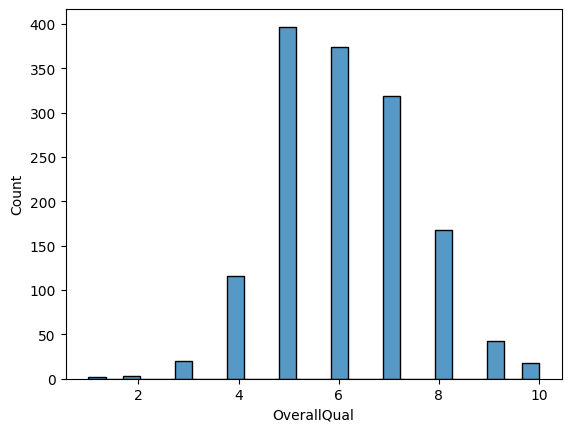

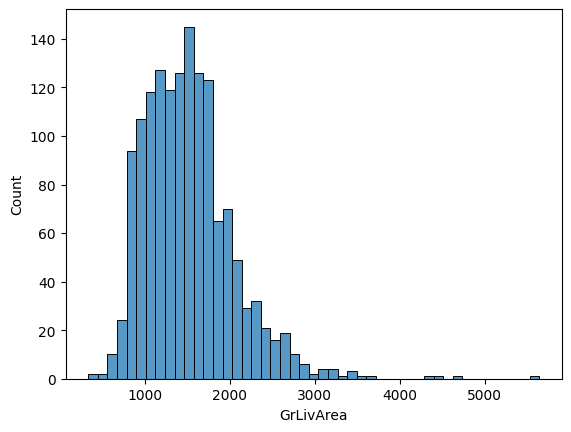

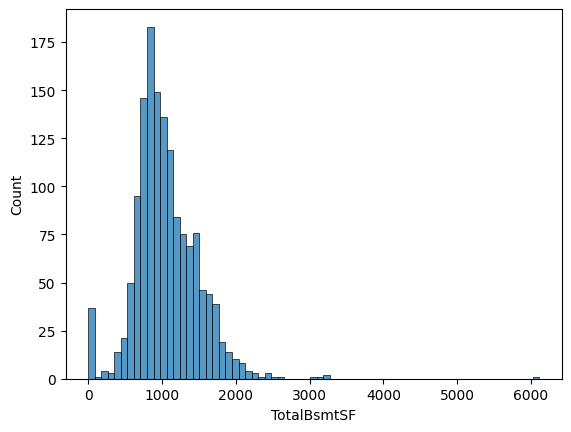

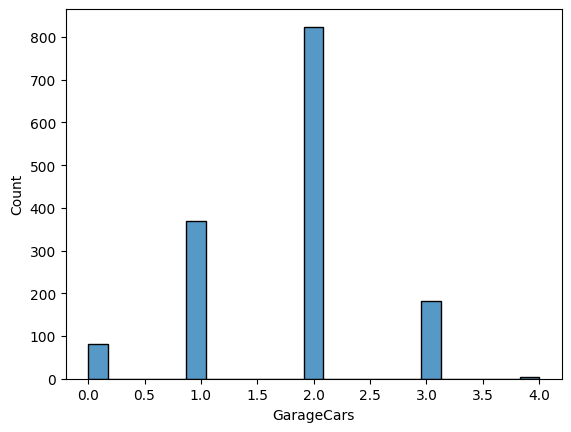

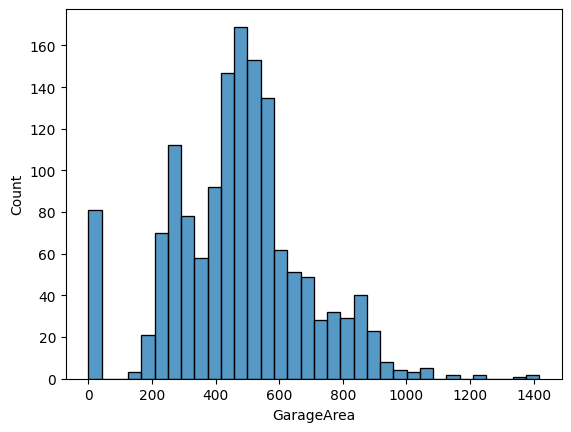

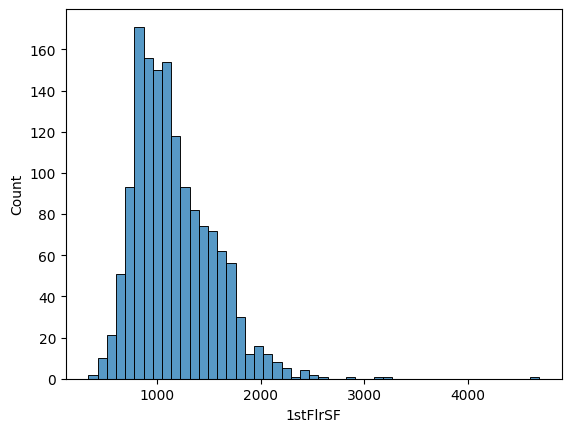

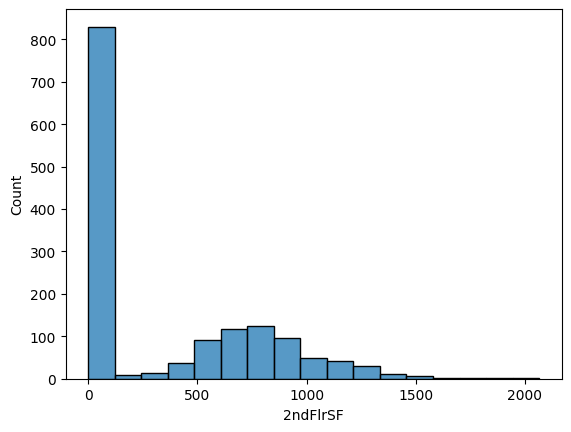

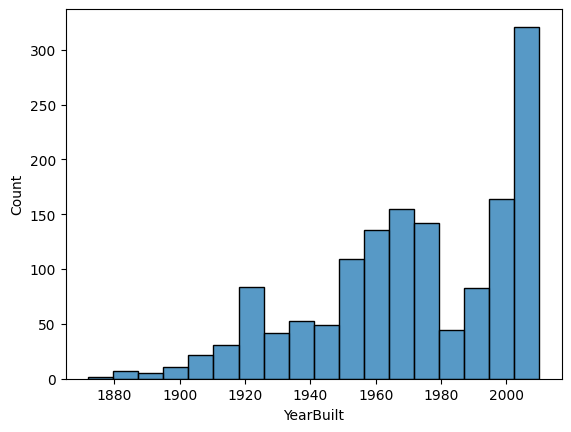

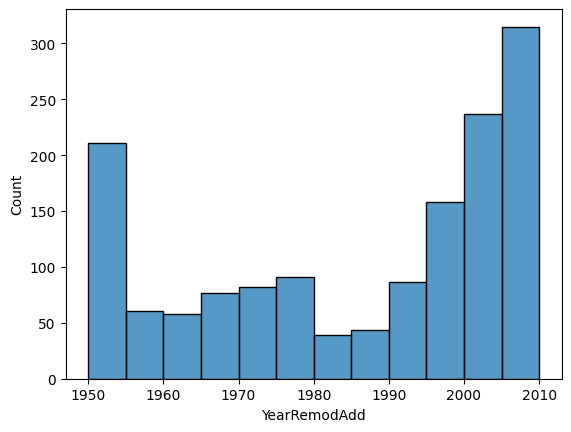

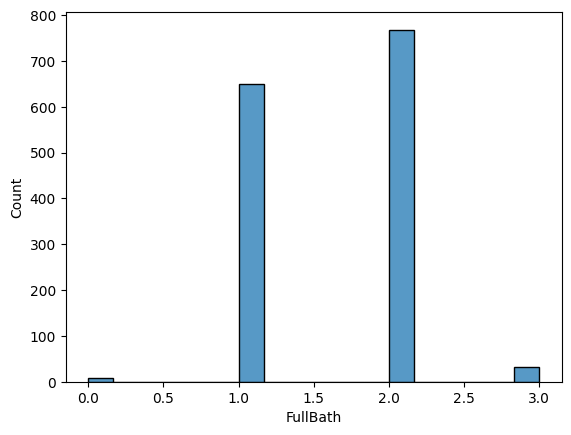

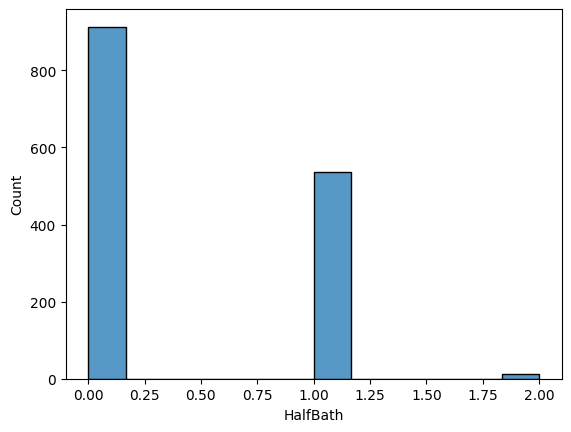

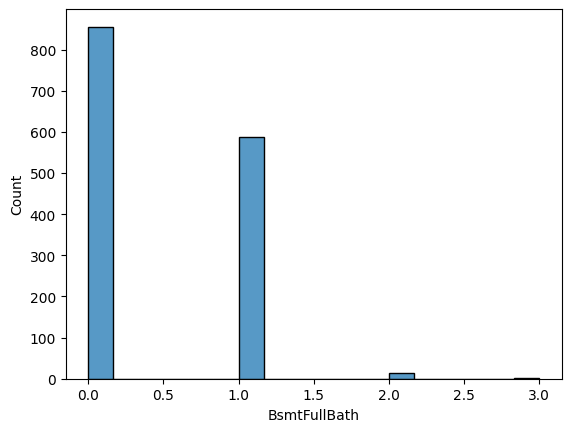

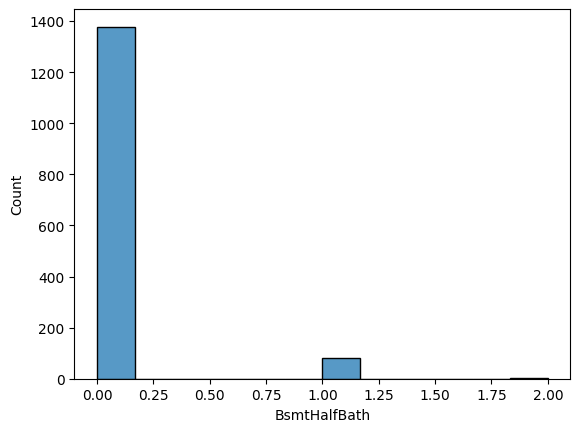

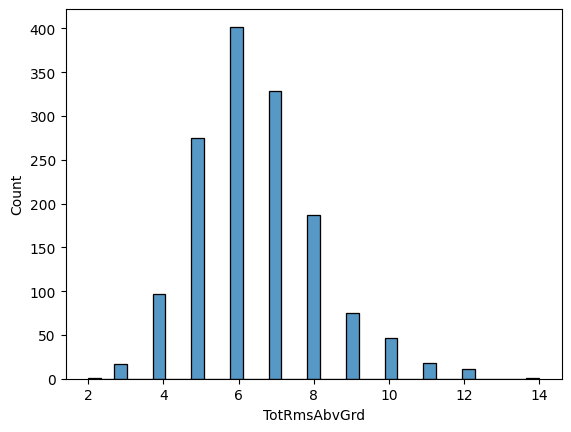

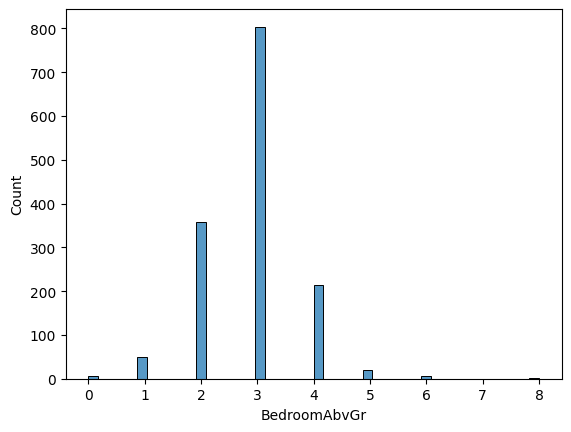

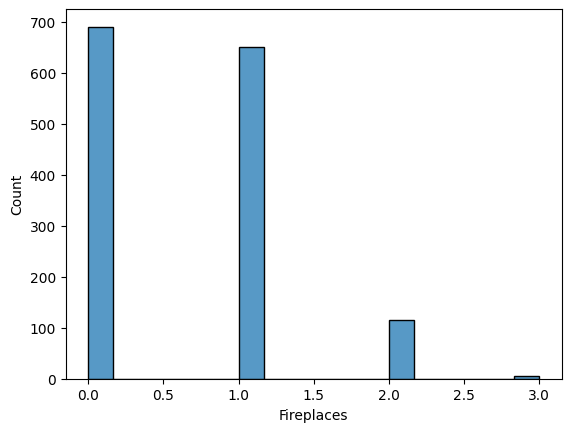

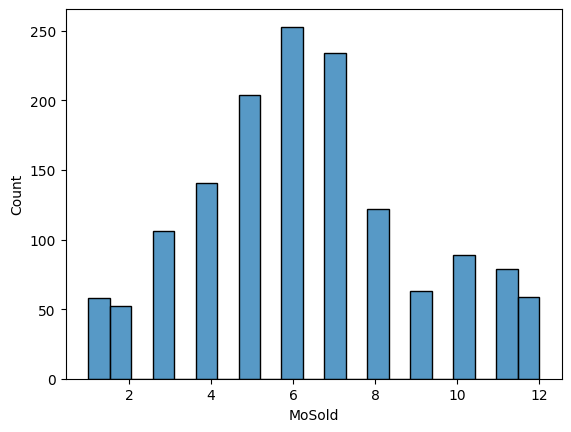

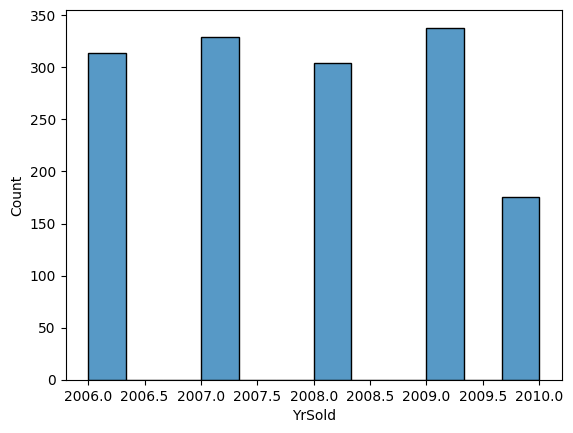

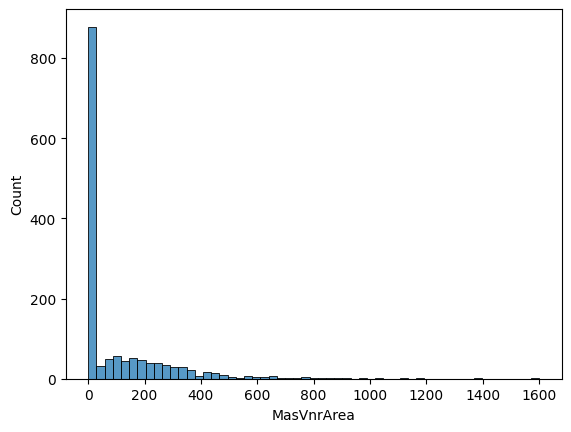

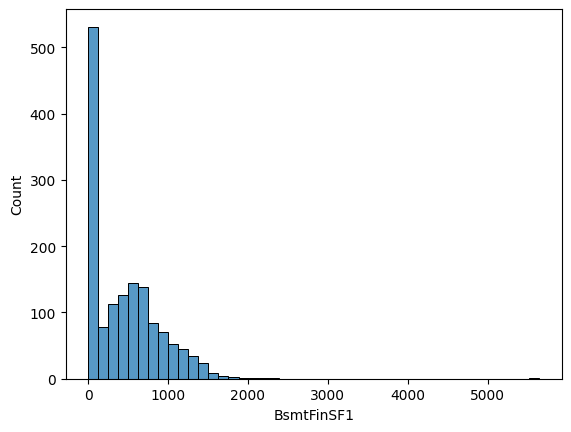

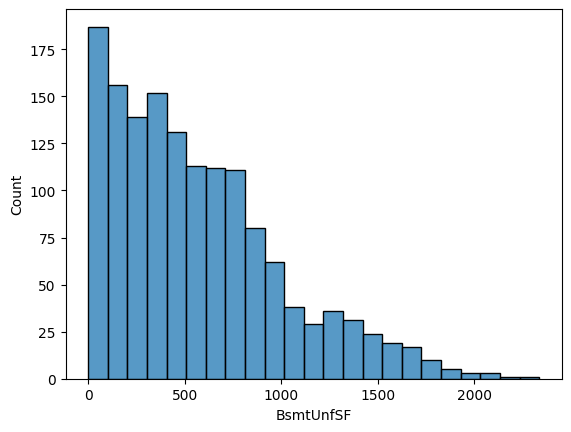

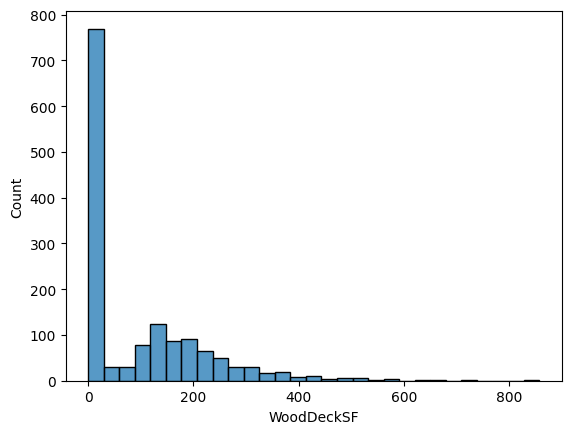

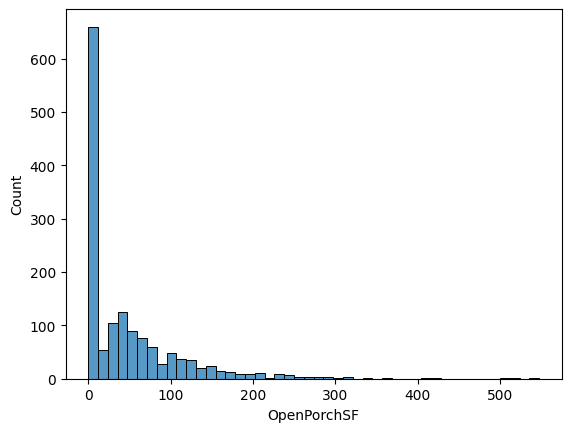

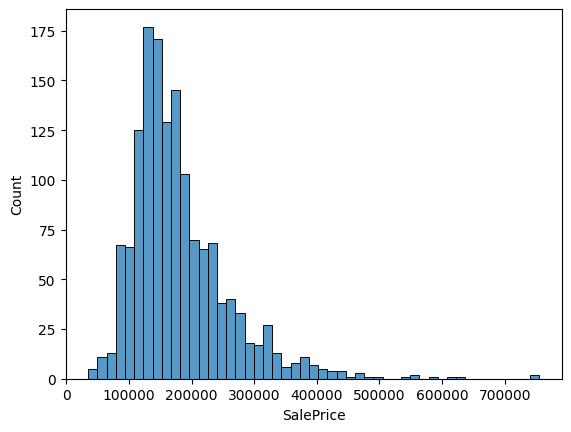

In [16]:
for i in train.select_dtypes(include='number').columns:
    sns.histplot(data=train,x=i)
    plt.show()

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   OverallQual   1460 non-null   int64  
 1   GrLivArea     1460 non-null   int64  
 2   TotalBsmtSF   1460 non-null   int64  
 3   GarageCars    1460 non-null   int64  
 4   GarageArea    1460 non-null   int64  
 5   1stFlrSF      1460 non-null   int64  
 6   2ndFlrSF      1460 non-null   int64  
 7   YearBuilt     1460 non-null   int64  
 8   YearRemodAdd  1460 non-null   int64  
 9   FullBath      1460 non-null   int64  
 10  HalfBath      1460 non-null   int64  
 11  BsmtFullBath  1460 non-null   int64  
 12  BsmtHalfBath  1460 non-null   int64  
 13  TotRmsAbvGrd  1460 non-null   int64  
 14  BedroomAbvGr  1460 non-null   int64  
 15  KitchenQual   1460 non-null   object 
 16  Fireplaces    1460 non-null   int64  
 17  Foundation    1460 non-null   object 
 18  ExterQual     1460 non-null 

In [18]:
train['KitchenQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [19]:
train['Foundation'].unique()

array(['PConc', 'CBlock', 'BrkTil', 'Wood', 'Slab', 'Stone'], dtype=object)

In [20]:
train['ExterQual'].unique()

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

In [21]:
train['Neighborhood'].unique()

array(['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',
       'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes',
       'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert',
       'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU',
       'Blueste'], dtype=object)

In [22]:
train['GarageFinish'].unique()

array(['RFn', 'Unf', 'Fin', nan], dtype=object)

In [23]:
train['CentralAir'].unique()

array(['Y', 'N'], dtype=object)

In [24]:
train['HouseStyle'].unique()

array(['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf',
       '2.5Fin'], dtype=object)

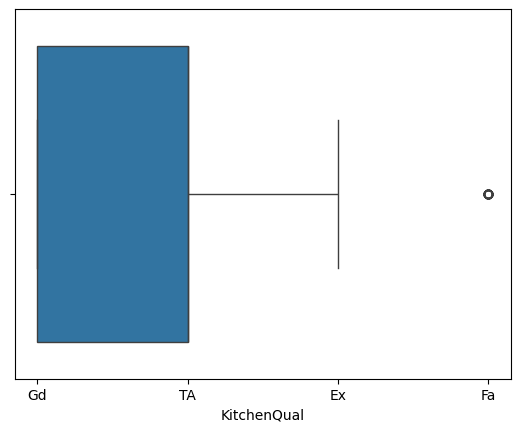

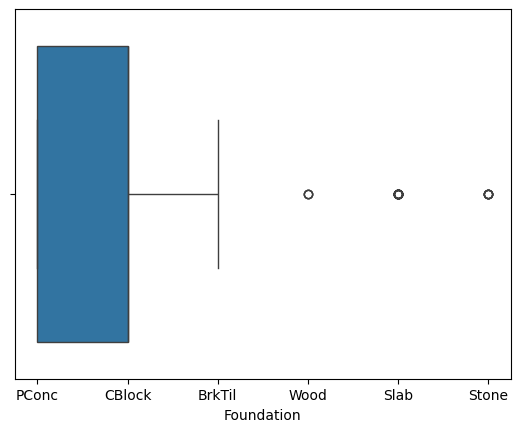

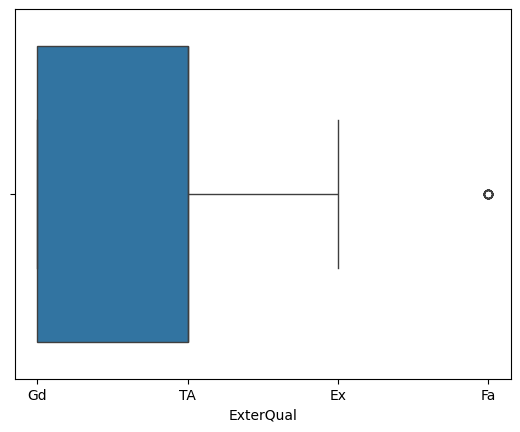

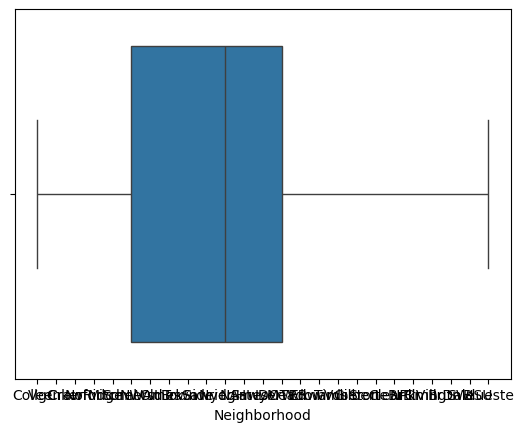

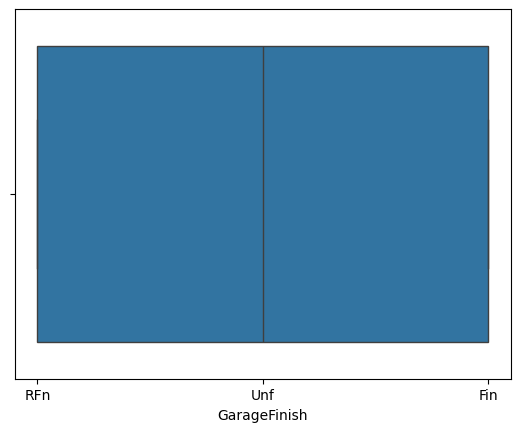

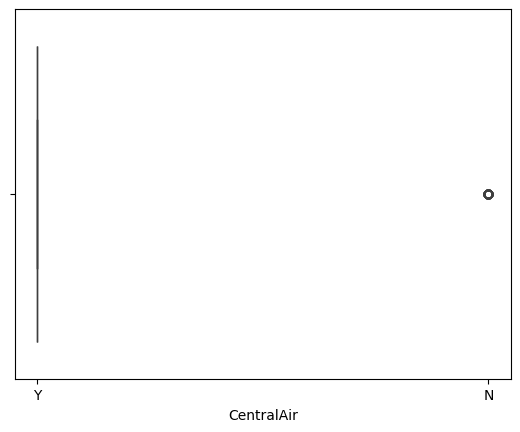

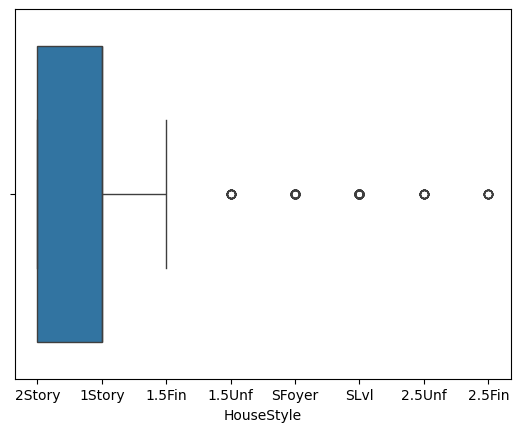

In [25]:
for i in train.select_dtypes(include='object').columns:
    sns.boxplot(data=train,x=i)
    plt.show()

In [26]:
train['GarageFinish'].isnull().sum()

81

In [27]:
train['GarageFinish'].mode()

0    Unf
Name: GarageFinish, dtype: object

In [28]:
garage_finish_map = {'Unf': 1, 'RFn': 2, 'Fin': 3}
train1 = {"Fa":1 , "TA":2 , "Gd":3 , "Ex":4}

In [29]:
def fill(df):
    for i in ["GarageFinish"]:
        print(f"Filling missing values in: {i}")
        print("Column exists:", i in df.columns)
        print("Null count:", df[i].isnull().sum())
        print("Mode value:", df[i].mode())
        if not df[i].mode().empty:
            df[i].fillna(df[i].mode()[0], inplace=True)
    return df

In [30]:
def encodage(df):
    df['KitchenQual'] = df['KitchenQual'].map(train1)
    df['ExterQual'] = df['ExterQual'].map(train1)
    df['GarageFinish'] = df['GarageFinish'].map(garage_finish_map)
    onehot_cols = ['Foundation', 'Neighborhood', 'CentralAir', 'MoSold', 'YrSold', 'HouseStyle']
    df = pd.get_dummies(df, columns=onehot_cols)
    return df

In [31]:
print(train.isnull().sum().sum())

89


In [32]:
print(test.isnull().sum().sum())

103


In [33]:
test = fill(test)
test = encodage(test)
train = fill(train)
train = encodage(train)
train, test = train.align(test, join='left', axis=1, fill_value=0)

Filling missing values in: GarageFinish
Column exists: True
Null count: 78
Mode value: 0    Unf
Name: GarageFinish, dtype: object
Filling missing values in: GarageFinish
Column exists: True
Null count: 81
Mode value: 0    Unf
Name: GarageFinish, dtype: object


In [34]:
train

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,GarageArea,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold_2009,YrSold_2010,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,7,1710,856,2,548,856,854,2003,2003,2,...,False,False,False,False,False,False,False,True,False,False
1,6,1262,1262,2,460,1262,0,1976,1976,2,...,False,False,False,False,True,False,False,False,False,False
2,7,1786,920,2,608,920,866,2001,2002,2,...,False,False,False,False,False,False,False,True,False,False
3,7,1717,756,3,642,961,756,1915,1970,1,...,False,False,False,False,False,False,False,True,False,False
4,8,2198,1145,3,836,1145,1053,2000,2000,2,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,953,2,460,953,694,1999,2000,2,...,False,False,False,False,False,False,False,True,False,False
1456,6,2073,1542,2,500,2073,0,1978,1988,2,...,False,True,False,False,True,False,False,False,False,False
1457,7,2340,1152,1,252,1188,1152,1941,2006,2,...,False,True,False,False,False,False,False,True,False,False
1458,5,1078,1078,1,240,1078,0,1950,1996,1,...,False,True,False,False,True,False,False,False,False,False


In [35]:
test

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,GarageArea,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold_2009,YrSold_2010,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,5,896,882.0,1.0,730.0,896,0,1961,1961,1,...,False,True,False,False,True,0,False,False,False,False
1,6,1329,1329.0,1.0,312.0,1329,0,1958,1958,1,...,False,True,False,False,True,0,False,False,False,False
2,5,1629,928.0,2.0,482.0,928,701,1997,1998,2,...,False,True,False,False,False,0,False,True,False,False
3,6,1604,926.0,2.0,470.0,926,678,1998,1998,2,...,False,True,False,False,False,0,False,True,False,False
4,8,1280,1280.0,2.0,506.0,1280,0,1992,1992,2,...,False,True,False,False,True,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,4,1092,546.0,0.0,0.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1455,4,1092,546.0,1.0,286.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1456,5,1224,1224.0,2.0,576.0,1224,0,1960,1996,1,...,False,False,False,False,True,0,False,False,False,False
1457,5,970,912.0,0.0,0.0,970,0,1992,1992,1,...,False,False,False,False,False,0,False,False,True,False


In [36]:
def all(model):
    model.fit(X_train,Y_train)
    pre = model.predict(X_train)
    rmse = mean_squared_error(Y_train, pre, squared=False)
    print("Accuracy is " ,rmse)
    rmse_v2.append(rmse)

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

model1 = LinearRegression()
model2 = LogisticRegression(max_iter=200)
model3 = RandomForestRegressor()
model4 = GradientBoostingRegressor()
model5 = XGBRegressor()

In [38]:
print(train.isnull().sum().sort_values(ascending=False).head(10))

MasVnrArea              8
OverallQual             0
Neighborhood_StoneBr    0
MoSold_3                0
MoSold_2                0
MoSold_1                0
CentralAir_Y            0
CentralAir_N            0
Neighborhood_Veenker    0
Neighborhood_Timber     0
dtype: int64


In [39]:
X = train.drop(['SalePrice'],axis = 1)
Y = train.SalePrice
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=.8)
rmse_v2 = []

In [40]:
train

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,GarageArea,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold_2009,YrSold_2010,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,7,1710,856,2,548,856,854,2003,2003,2,...,False,False,False,False,False,False,False,True,False,False
1,6,1262,1262,2,460,1262,0,1976,1976,2,...,False,False,False,False,True,False,False,False,False,False
2,7,1786,920,2,608,920,866,2001,2002,2,...,False,False,False,False,False,False,False,True,False,False
3,7,1717,756,3,642,961,756,1915,1970,1,...,False,False,False,False,False,False,False,True,False,False
4,8,2198,1145,3,836,1145,1053,2000,2000,2,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,6,1647,953,2,460,953,694,1999,2000,2,...,False,False,False,False,False,False,False,True,False,False
1456,6,2073,1542,2,500,2073,0,1978,1988,2,...,False,True,False,False,True,False,False,False,False,False
1457,7,2340,1152,1,252,1188,1152,1941,2006,2,...,False,True,False,False,False,False,False,True,False,False
1458,5,1078,1078,1,240,1078,0,1950,1996,1,...,False,True,False,False,True,False,False,False,False,False


In [41]:
test

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,GarageArea,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold_2009,YrSold_2010,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,5,896,882.0,1.0,730.0,896,0,1961,1961,1,...,False,True,False,False,True,0,False,False,False,False
1,6,1329,1329.0,1.0,312.0,1329,0,1958,1958,1,...,False,True,False,False,True,0,False,False,False,False
2,5,1629,928.0,2.0,482.0,928,701,1997,1998,2,...,False,True,False,False,False,0,False,True,False,False
3,6,1604,926.0,2.0,470.0,926,678,1998,1998,2,...,False,True,False,False,False,0,False,True,False,False
4,8,1280,1280.0,2.0,506.0,1280,0,1992,1992,2,...,False,True,False,False,True,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,4,1092,546.0,0.0,0.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1455,4,1092,546.0,1.0,286.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1456,5,1224,1224.0,2.0,576.0,1224,0,1960,1996,1,...,False,False,False,False,True,0,False,False,False,False
1457,5,970,912.0,0.0,0.0,970,0,1992,1992,1,...,False,False,False,False,False,0,False,False,True,False


In [42]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')  # or 'most_frequent' for categorical
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.fit_transform(X_test), columns=X_test.columns)


In [43]:
all(model1)
all(model2)
all(model3)
all(model4)
all(model5)

Accuracy is  32872.45126922951


c:\users\ihab\appdata\local\programs\python\python38\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy is  36601.90729022921
Accuracy is  12022.572220896825
Accuracy is  16352.008805747471
Accuracy is  1551.395810956512


In [44]:
print(X_train.isnull().values.any())  # Should return False

False


In [45]:
from sklearn.metrics import mean_squared_error

mean_price = train['SalePrice'].mean()
baseline_preds = [mean_price] * len(Y_test)
rmse_baseline = np.sqrt(mean_squared_error(Y_test, baseline_preds))
print("Baseline RMSE:", rmse_baseline)


Baseline RMSE: 72094.13528989452


In [46]:
modelv2 = XGBRegressor()
modelv2.fit(X_train,Y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [47]:
if 'SalePrice' in test.columns:
    test = test.drop(columns=['SalePrice'])
xgb = modelv2.predict(test)

In [49]:
xgb

array([134269.28, 165400.58, 181460.77, ..., 152821.47, 104018.8 ,
       208488.7 ], dtype=float32)

In [61]:
test2 = pd.read_csv(path_test)
test2.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [60]:
test

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,GarageArea,1stFlrSF,2ndFlrSF,YearBuilt,YearRemodAdd,FullBath,...,YrSold_2009,YrSold_2010,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,5,896,882.0,1.0,730.0,896,0,1961,1961,1,...,False,True,False,False,True,0,False,False,False,False
1,6,1329,1329.0,1.0,312.0,1329,0,1958,1958,1,...,False,True,False,False,True,0,False,False,False,False
2,5,1629,928.0,2.0,482.0,928,701,1997,1998,2,...,False,True,False,False,False,0,False,True,False,False
3,6,1604,926.0,2.0,470.0,926,678,1998,1998,2,...,False,True,False,False,False,0,False,True,False,False
4,8,1280,1280.0,2.0,506.0,1280,0,1992,1992,2,...,False,True,False,False,True,0,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,4,1092,546.0,0.0,0.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1455,4,1092,546.0,1.0,286.0,546,546,1970,1970,1,...,False,False,False,False,False,0,False,True,False,False
1456,5,1224,1224.0,2.0,576.0,1224,0,1960,1996,1,...,False,False,False,False,True,0,False,False,False,False
1457,5,970,912.0,0.0,0.0,970,0,1992,1992,1,...,False,False,False,False,False,0,False,False,True,False


In [62]:
ids = test2['Id'].copy()
df = pd.DataFrame({
    'Id': ids,
    'SalePrice': xgb  # or y_pred, depending on what you called it
})

In [63]:
df.head()

,Id,SalePrice
0,1461,134269.281250
1,1462,165400.578125
2,1463,181460.765625
3,1464,195265.156250
4,1465,186891.968750


In [65]:
df.to_csv('submissionv3.csv',index=False)